Preprocessing



In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset
import joblib

df = pd.read_csv("macro.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# 결측: forward-only로 (누수 방지)
df = df.ffill().interpolate(limit_direction="forward")

# 변환
df_tr = pd.DataFrame({
    "PMI": df["PMI"],
    "GS10": df["GS10"],
    "LOG_M2": np.log(df["M2SL"]),
    "UNRATE": df["UNRATE"],
    "INFLATION": np.log(df["CPIAUCSL"]).diff(),
    "LOG_INDPRO": np.log(df["INDPRO"]),
}, index=df.index).dropna()

# ===== time split 먼저 =====
T = len(df_tr)
n_train = int(T * 0.8)
n_val   = int(T * 0.1)
train_df = df_tr.iloc[:n_train]
val_df   = df_tr.iloc[n_train:n_train+n_val]
test_df  = df_tr.iloc[n_train+n_val:]

# ===== scaler는 train에만 fit =====
scaler = StandardScaler()
train_np = scaler.fit_transform(train_df.values)
val_np   = scaler.transform(val_df.values)
test_np  = scaler.transform(test_df.values)

joblib.dump(scaler, "macro_scaler.pkl")

class MacroDataset(Dataset):
    def __init__(self, data_np, L=36, H=12):
        self.data = torch.from_numpy(data_np).float()  # (T, 6)
        self.L, self.H = L, H

    def __len__(self):
        return len(self.data) - (self.L + self.H) + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.L]                      # (L, 6)
        y = self.data[idx+self.L:idx+self.L+self.H]        # (H, 6)
        x = x.transpose(0, 1).contiguous()                 # (6, L)
        return x, y

L, H = 36, 12
train_ds = MacroDataset(train_np, L, H)
val_ds   = MacroDataset(val_np, L, H)
test_ds  = MacroDataset(test_np, L, H)

print(len(train_ds), len(val_ds), len(test_ds))


489 20 20


Encoder

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

###############################################
#  1) TCN Building Blocks (이미 위에 있음)
###############################################
from torch.nn.utils import weight_norm

def kl_gaussian(mu, logvar):
    """
    KL( N(mu, sigma^2) || N(0, I) ), diag 가정
    mu: (B, latent_dim)
    logvar: (B, latent_dim)
    """
    # sigma^2 = exp(logvar)
    # 공식: 0.5 * Σ( exp(logvar) + mu^2 - 1 - logvar )
    return 0.5 * torch.mean(
        torch.sum(
            torch.exp(logvar) + mu**2 - 1.0 - logvar,
            dim=1
        )
    )


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs,
                 kernel_size, dilation, dropout=0.15):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = weight_norm(
            nn.Conv1d(
                n_inputs,
                n_outputs,
                kernel_size,
                padding=padding,
                dilation=dilation,
            )
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(
            nn.Conv1d(
                n_outputs,
                n_outputs,
                kernel_size,
                padding=padding,
                dilation=dilation,
            )
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(n_inputs, n_outputs, 1)
            if n_inputs != n_outputs
            else None
        )
        self.relu = nn.ReLU()

        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels,
                 kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = num_inputs if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            layers.append(
                TemporalBlock(
                    n_inputs=in_ch,
                    n_outputs=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

###############################################
#  2) MacroEncoder + Forecast Head
###############################################

class MacroEncoder(nn.Module):
    """
    Macro-only Encoder for pretraining.
    x: (B, F=6, L=36)  ->  z: (B, latent_dim)
    """
    def __init__(self, input_dim=6, hidden_dim=128, latent_dim=32,
                 num_layers=4, kernel_size=3, dropout=0.15):
        super().__init__()

        # 1) input projection: F -> hidden
        self.input_proj = nn.Conv1d(input_dim, hidden_dim, kernel_size=1)

        # 2) TCN backbone (hidden -> hidden)
        self.tcn = TemporalConvNet(
            num_inputs=hidden_dim,
            num_channels=[hidden_dim] * num_layers,
            kernel_size=kernel_size,
            dropout=dropout,
        )

        # 3) Latent heads
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        x: (B, F, L)
        """
        h = self.input_proj(x)       # (B, hidden, L)
        h = self.tcn(h)              # (B, hidden, L)
        h_last = h[:, :, -1]         # (B, hidden)

        mu = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last)
        return mu, logvar


class MacroForecastModel(nn.Module):
    """
    Encoder + 작은 Forecast Head
    - Encoder는 VAE-style latent를 뽑고
    - Head가 미래 H 스텝 전체를 예측
    """
    def __init__(self, input_dim=6, hidden_dim=128, latent_dim=32,
                 num_layers=4, kernel_size=3, dropout=0.15, H=12):
        super().__init__()
        self.encoder = MacroEncoder(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            num_layers=num_layers,
            kernel_size=kernel_size,
            dropout=dropout,
        )
        self.latent_dim = latent_dim
        self.H = H
        self.input_dim = input_dim

        # Forecast head: z -> future window (H * F)
        self.head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, H * input_dim),
        )

    def reparameterize(self, mu, logvar):
        eps = torch.randn_like(mu)
        std = torch.exp(0.5 * logvar)
        return mu + eps * std

    def forward(self, x):
        """
        x: (B, F, L)
        return:
          y_pred: (B, H, F)
          mu, logvar, z
        """
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        out = self.head(z)                         # (B, H*F)
        y_pred = out.view(-1, self.H, self.input_dim)  # (B, H, F)
        return y_pred, mu, logvar, z


Train

In [25]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def train_macro_pretrain(
    train_ds,
    val_ds,
    input_dim=6,
    latent_dim=32,
    hidden_dim=128,
    H=12,
    lr=1e-3,
    batch_size=32,
    epochs=80,
    beta_max=0.01,    # KL weight (작게 하는 게 안정적)
    warmup_ratio=0.2,
    device="cuda" if torch.cuda.is_available() else "cpu"
):

    device = torch.device(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = MacroForecastModel(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        H=H,
    ).to(device)

    optim = torch.optim.Adam(model.parameters(), lr=lr)

    # history 기록
    history = {
        "tr_loss": [], "tr_mse": [], "tr_kl": [],
        "va_loss": [], "va_mse": [], "va_kl": [],
        "beta": []
    }

    warmup_epochs = int(epochs * warmup_ratio)

    print("===== MACRO PRETRAIN (with Validation) =====")
    for epoch in range(1, epochs+1):

        # --------- KL Annealing ---------
        if epoch <= warmup_epochs:
            beta = 0.0
        else:
            t = (epoch - warmup_epochs) / (epochs - warmup_epochs)
            beta = beta_max * min(1.0, t)
        history["beta"].append(beta)

        # ───────────────────────────────────
        #              TRAIN
        # ───────────────────────────────────
        model.train()
        total_loss=total_mse=total_kl=0
        n=0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            y_pred, mu, logvar, _ = model(xb)
            mse = F.mse_loss(y_pred, yb)
            kl  = kl_gaussian(mu, logvar)
            loss = mse + beta * kl

            optim.zero_grad()
            loss.backward()
            optim.step()

            total_loss += loss.item() * xb.size(0)
            total_mse  += mse.item()  * xb.size(0)
            total_kl   += kl.item()   * xb.size(0)
            n += xb.size(0)

        tr_loss = total_loss/n
        tr_mse  = total_mse/n
        tr_kl   = total_kl/n

        history["tr_loss"].append(tr_loss)
        history["tr_mse"].append(tr_mse)
        history["tr_kl"].append(tr_kl)

        # ───────────────────────────────────
        #             VALIDATION
        # ───────────────────────────────────
        model.eval()
        total_loss=total_mse=total_kl=0
        n=0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                y_pred, mu, logvar, _ = model(xb)
                mse = F.mse_loss(y_pred, yb)
                kl  = kl_gaussian(mu, logvar)
                loss = mse + beta * kl

                total_loss += loss.item() * xb.size(0)
                total_mse  += mse.item()  * xb.size(0)
                total_kl   += kl.item()   * xb.size(0)
                n += xb.size(0)

        va_loss = total_loss/n
        va_mse  = total_mse/n
        va_kl   = total_kl/n

        history["va_loss"].append(va_loss)
        history["va_mse"].append(va_mse)
        history["va_kl"].append(va_kl)

        print(f"[{epoch:03d}/{epochs}] "
              f"TR Loss={tr_loss:.4f} MSE={tr_mse:.4f} KL={tr_kl:.4f} | "
              f"VAL Loss={va_loss:.4f} MSE={va_mse:.4f} KL={va_kl:.4f} | "
              f"beta={beta:.4f}")

    return model, history


In [26]:
model, history = train_macro_pretrain(
    train_ds,
    val_ds,
    input_dim=6,
    latent_dim=32,
    hidden_dim=128,
    H=12,
    epochs=80,
)


===== MACRO PRETRAIN (with Validation) =====


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


[001/80] TR Loss=0.7786 MSE=0.7786 KL=38.7750 | VAL Loss=0.6358 MSE=0.6358 KL=91.8676 | beta=0.0000
[002/80] TR Loss=0.4673 MSE=0.4673 KL=78.6342 | VAL Loss=0.4833 MSE=0.4833 KL=134.7530 | beta=0.0000
[003/80] TR Loss=0.3489 MSE=0.3489 KL=104.5529 | VAL Loss=0.3437 MSE=0.3437 KL=162.2985 | beta=0.0000
[004/80] TR Loss=0.2942 MSE=0.2942 KL=99.3175 | VAL Loss=0.3093 MSE=0.3093 KL=148.9534 | beta=0.0000
[005/80] TR Loss=0.2545 MSE=0.2545 KL=104.3068 | VAL Loss=0.2738 MSE=0.2738 KL=186.7017 | beta=0.0000
[006/80] TR Loss=0.2273 MSE=0.2273 KL=114.7203 | VAL Loss=0.2303 MSE=0.2303 KL=186.8136 | beta=0.0000
[007/80] TR Loss=0.2140 MSE=0.2140 KL=117.5531 | VAL Loss=0.2978 MSE=0.2978 KL=172.8320 | beta=0.0000
[008/80] TR Loss=0.2001 MSE=0.2001 KL=114.2233 | VAL Loss=0.2533 MSE=0.2533 KL=193.2915 | beta=0.0000
[009/80] TR Loss=0.1870 MSE=0.1870 KL=119.4986 | VAL Loss=0.2868 MSE=0.2868 KL=185.7599 | beta=0.0000
[010/80] TR Loss=0.1850 MSE=0.1850 KL=116.2960 | VAL Loss=0.3741 MSE=0.3741 KL=156.677

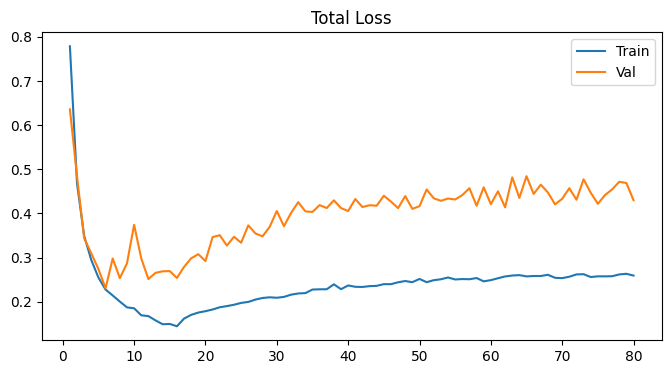

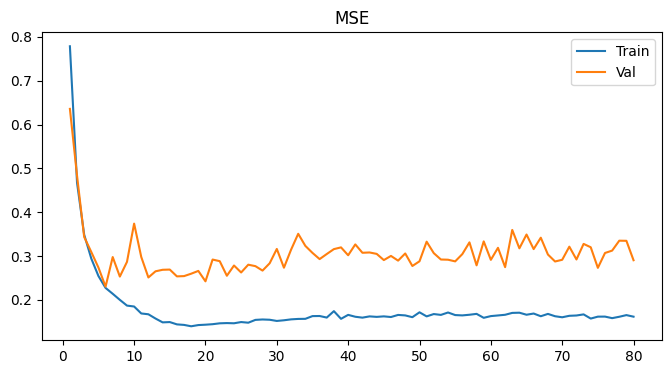

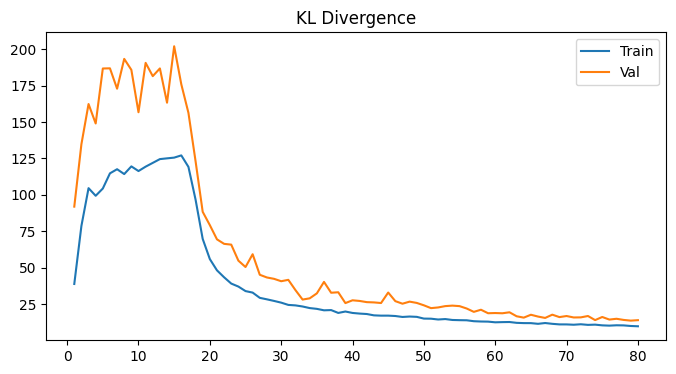

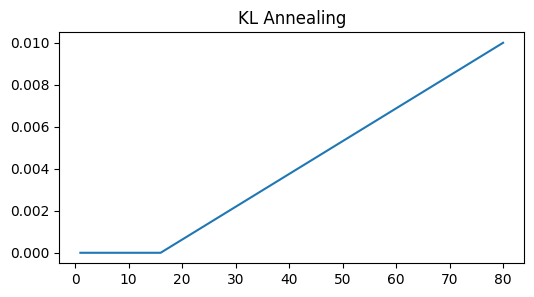

In [27]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["tr_loss"]) + 1)

# ----- Total Loss -----
plt.figure(figsize=(8,4))
plt.plot(epochs, history["tr_loss"], label="Train")
plt.plot(epochs, history["va_loss"], label="Val")
plt.title("Total Loss")
plt.legend(); plt.show()

# ----- MSE -----
plt.figure(figsize=(8,4))
plt.plot(epochs, history["tr_mse"], label="Train")
plt.plot(epochs, history["va_mse"], label="Val")
plt.title("MSE")
plt.legend(); plt.show()

# ----- KL -----
plt.figure(figsize=(8,4))
plt.plot(epochs, history["tr_kl"], label="Train")
plt.plot(epochs, history["va_kl"], label="Val")
plt.title("KL Divergence")
plt.legend(); plt.show()

# ----- Beta -----
plt.figure(figsize=(6,3))
plt.plot(epochs, history["beta"])
plt.title("KL Annealing")
plt.show()


PCA

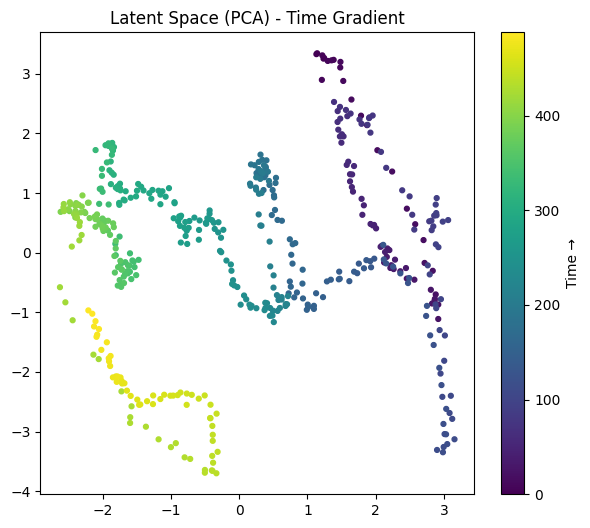

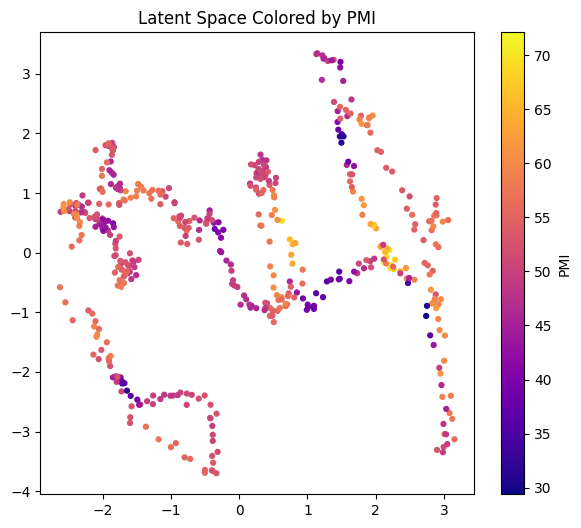

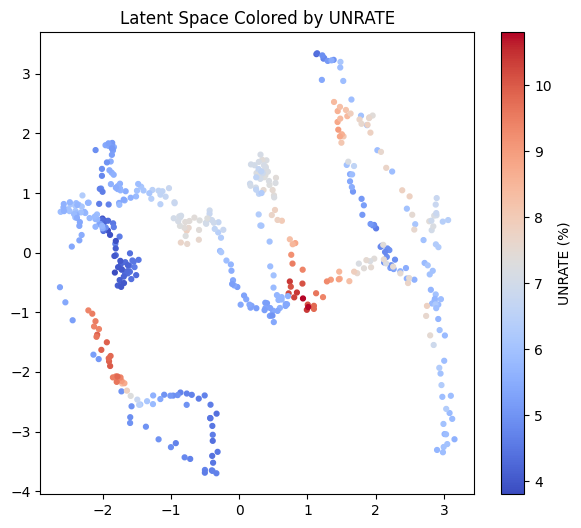

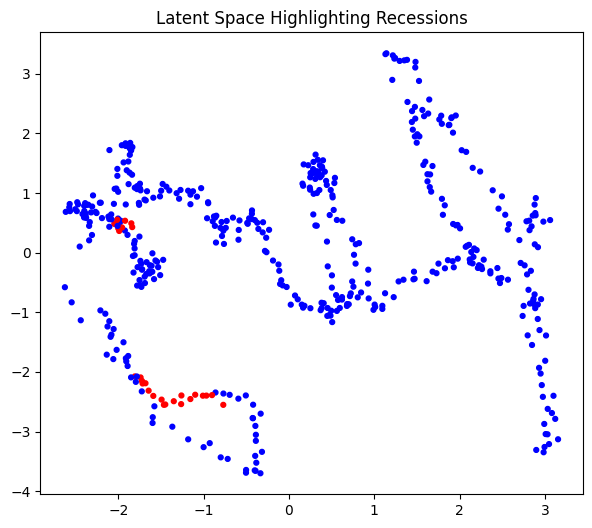

In [28]:
import torch
from torch.utils.data import DataLoader
import numpy as np

def extract_latents(model, dataset, device="cuda"):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    model.eval()
    zs = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            mu, logvar = model.encoder(xb)
            zs.append(mu.cpu().numpy())

    return np.concatenate(zs, axis=0)   # (N, latent_dim)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

z = extract_latents(model, train_ds, device="cuda")
pca = PCA(n_components=2)
z2 = pca.fit_transform(z)

plt.figure(figsize=(7,6))
plt.scatter(z2[:,0], z2[:,1], c=np.arange(len(z2)), cmap="viridis", s=12)
plt.title("Latent Space (PCA) - Time Gradient")
plt.colorbar(label="Time →")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(z2[:,0], z2[:,1], c=train_df["PMI"].values[:len(z2)], cmap="plasma", s=12)
plt.title("Latent Space Colored by PMI")
plt.colorbar(label="PMI")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(z2[:,0], z2[:,1], c=train_df["UNRATE"].values[:len(z2)], cmap="coolwarm", s=12)
plt.title("Latent Space Colored by UNRATE")
plt.colorbar(label="UNRATE (%)")
plt.show()

recessions = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01")
]

# recession mask
mask = np.zeros(len(train_df), dtype=bool)
for start, end in recessions:
    mask |= (train_df.index >= start) & (train_df.index <= end)

plt.figure(figsize=(7,6))
plt.scatter(z2[:,0], z2[:,1], c=mask[:len(z2)], cmap="bwr", s=12)
plt.title("Latent Space Highlighting Recessions")
plt.show()
